# E-Commerce Sales Prediction Using a Neural Network

**Scenario:** Zenith Electronics wants to use historical e-commerce transaction data to support inventory and marketing decisions.

**Goal:** Build and tune a Multi-layer Perceptron neural network to predict e-commerce sales.

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 3. Load the Dataset

The dataset file must be in the same folder as this notebook and must be named `Online Retail.xlsx`.

In [2]:
df = pd.read_excel("Online Retail.xlsx", engine="openpyxl")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 4. Explore the Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
df.isnull().sum().sort_values(ascending=False)

CustomerID     135080
Description      1454
StockCode           0
InvoiceNo           0
Quantity            0
InvoiceDate         0
UnitPrice           0
Country             0
dtype: int64

## 5. Clean the Data

The raw data includes cancelled invoices, missing descriptions, negative quantities, and unusual transaction values. These rows are cleaned before model training.

In [6]:
data = df.copy()

# Remove rows missing key modeling fields.
data = data.dropna(subset=["InvoiceNo", "Description", "Quantity", "InvoiceDate", "UnitPrice", "Country"])

# Remove cancelled invoices. In this dataset, cancelled invoice numbers usually start with C.
data = data[~data["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid quantities and prices.
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]

# Create the sales target.
data["TotalSales"] = data["Quantity"] * data["UnitPrice"]

# Remove extreme outliers so the neural network is not dominated by rare wholesale-like transactions.
sales_cap = data["TotalSales"].quantile(0.99)
data = data[data["TotalSales"] <= sales_cap]

print("Cleaned shape:", data.shape)
print("99th percentile sales cap:", round(sales_cap, 2))
data.head()

Cleaned shape: (524825, 9)
99th percentile sales cap: 183.6


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 6. Feature Engineering

The neural network cannot directly interpret dates, so date fields are converted into useful numeric features.

In [7]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

data["Month"] = data["InvoiceDate"].dt.month
data["DayOfWeek"] = data["InvoiceDate"].dt.dayofweek
data["Hour"] = data["InvoiceDate"].dt.hour
data["IsWeekend"] = data["DayOfWeek"].isin([5, 6]).astype(int)

data[["InvoiceDate", "Month", "DayOfWeek", "Hour", "IsWeekend", "TotalSales"]].head()

,InvoiceDate,Month,DayOfWeek,Hour,IsWeekend,TotalSales
0,2010-12-01 08:26:00,12,2,8,0,15.30
1,2010-12-01 08:26:00,12,2,8,0,20.34
2,2010-12-01 08:26:00,12,2,8,0,22.00
3,2010-12-01 08:26:00,12,2,8,0,20.34
4,2010-12-01 08:26:00,12,2,8,0,20.34


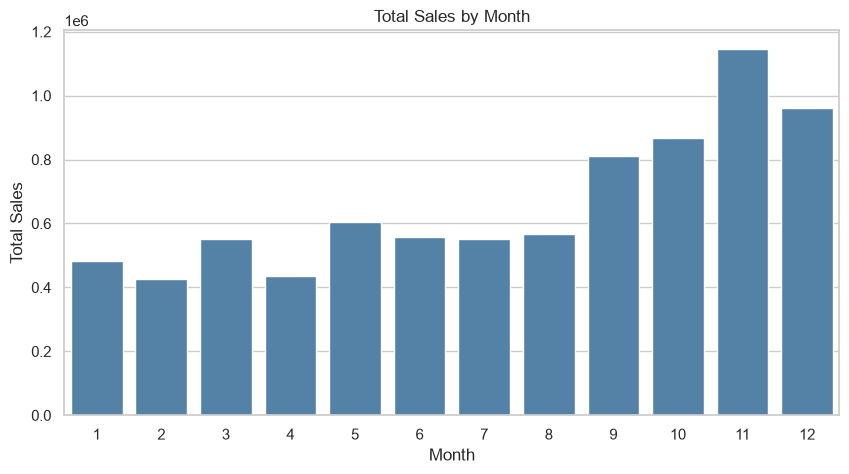

In [8]:
monthly_sales = data.groupby("Month", as_index=False)["TotalSales"].sum()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_sales, x="Month", y="TotalSales", color="steelblue")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## 7. Select Features and Target

In [9]:
features = ["Quantity", "UnitPrice", "Month", "DayOfWeek", "Hour", "IsWeekend", "Country"]
target = "TotalSales"

X = data[features]
y = data[target]

X.head()

,Quantity,UnitPrice,Month,DayOfWeek,Hour,IsWeekend,Country
0,6,2.55,12,2,8,0,United Kingdom
1,6,3.39,12,2,8,0,United Kingdom
2,8,2.75,12,2,8,0,United Kingdom
3,6,3.39,12,2,8,0,United Kingdom
4,6,3.39,12,2,8,0,United Kingdom


## 8. Split Training and Testing Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 419860
Testing rows: 104965


## 9. Preprocessing Pipeline

Numeric features are standardized because neural networks train better when inputs are on similar scales. The country column is one-hot encoded.

In [11]:
numeric_features = ["Quantity", "UnitPrice", "Month", "DayOfWeek", "Hour", "IsWeekend"]
categorical_features = ["Country"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 10. Baseline Neural Network Model

The baseline model uses one hidden layer. The Adam optimizer performs gradient-based weight updates, while `alpha` applies L2 regularization.

In [12]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64,),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            batch_size=256,
            early_stopping=True,
            max_iter=100,
            random_state=RANDOM_STATE
        ))
    ]
)

baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

In [13]:
baseline_mse = mean_squared_error(y_test, baseline_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print("Baseline MLP Results")
print("MSE:", round(baseline_mse, 2))
print("RMSE:", round(baseline_rmse, 2))
print("MAE:", round(baseline_mae, 2))
print("R-squared:", round(baseline_r2, 4))

Baseline MLP Results
MSE: 3.29
RMSE: 1.81
MAE: 0.84
R-squared: 0.9926


## 11. Hyperparameter Tuning

Grid search tests different hidden-layer structures, regularization values, learning rates, and batch sizes. To keep runtime manageable, the grid search uses a reproducible sample and then refits the best model on the full training set.

In [14]:
tuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", MLPRegressor(
            activation="relu",
            solver="adam",
            early_stopping=True,
            max_iter=100,
            random_state=RANDOM_STATE
        ))
    ]
)

param_grid = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001, 0.005],
    "model__batch_size": [128, 256]
}

tune_size = min(30000, len(X_train))
tune_index = X_train.sample(n=tune_size, random_state=RANDOM_STATE).index
X_tune = X_train.loc[tune_index]
y_tune = y_train.loc[tune_index]

grid_search = GridSearchCV(
    estimator=tuned_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tune, y_tune)

print("Best parameters:")
grid_search.best_params_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters:


{'model__alpha': 0.0001,
 'model__batch_size': 128,
 'model__hidden_layer_sizes': (64, 32),
 'model__learning_rate_init': 0.005}

## 12. Train and Evaluate the Tuned Model

In [15]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

tuned_predictions = best_model.predict(X_test)

tuned_mse = mean_squared_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(tuned_mse)
tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_r2 = r2_score(y_test, tuned_predictions)

print("Tuned MLP Results")
print("MSE:", round(tuned_mse, 2))
print("RMSE:", round(tuned_rmse, 2))
print("MAE:", round(tuned_mae, 2))
print("R-squared:", round(tuned_r2, 4))

Tuned MLP Results
MSE: 0.91
RMSE: 0.95
MAE: 0.42
R-squared: 0.998


## 13. Compare Models

In [16]:
results = pd.DataFrame({
    "Model": ["Baseline MLP", "Tuned MLP"],
    "MSE": [baseline_mse, tuned_mse],
    "RMSE": [baseline_rmse, tuned_rmse],
    "MAE": [baseline_mae, tuned_mae],
    "R-squared": [baseline_r2, tuned_r2]
})

results

,Model,MSE,RMSE,MAE,R-squared
0,Baseline MLP,3.288788,1.813502,0.837243,0.992609
1,Tuned MLP,0.911793,0.954878,0.422544,0.997951


## 14. Visualize Actual vs. Predicted Sales

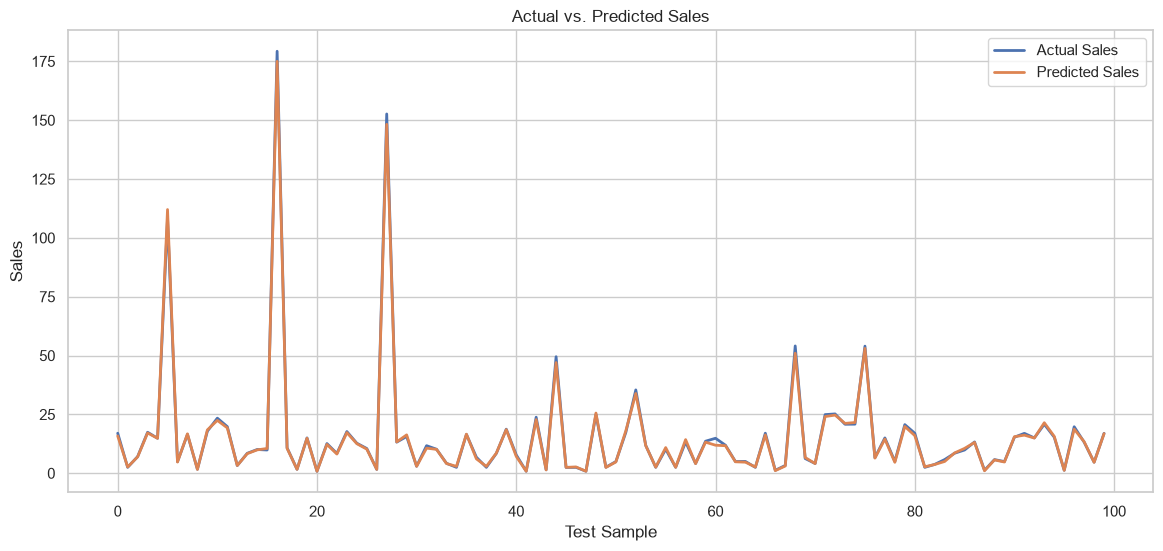

In [17]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values[:100],
    "Predicted Sales": tuned_predictions[:100]
})

plt.figure(figsize=(14, 6))
plt.plot(comparison["Actual Sales"].values, label="Actual Sales", linewidth=2)
plt.plot(comparison["Predicted Sales"].values, label="Predicted Sales", linewidth=2)
plt.title("Actual vs. Predicted Sales")
plt.xlabel("Test Sample")
plt.ylabel("Sales")
plt.legend()
plt.show()

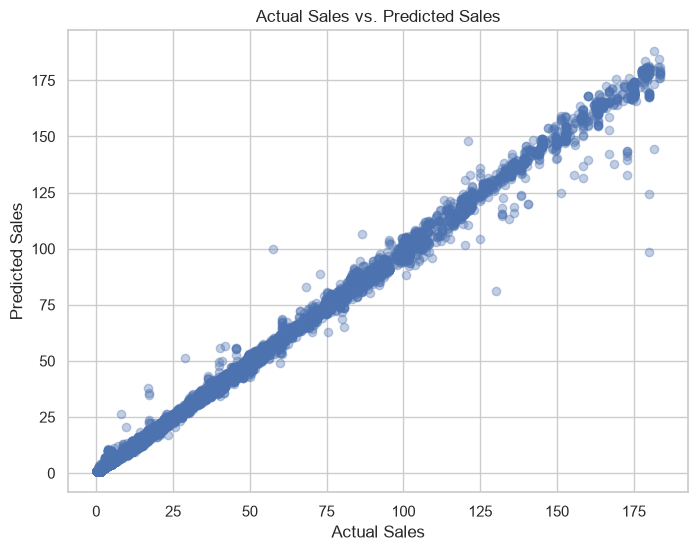

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, tuned_predictions, alpha=0.35)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs. Predicted Sales")
plt.show()

## 15. Save Model and Results

In [19]:
joblib.dump(best_model, "best_mlp_sales_model.pkl")
results.to_csv("model_results.csv", index=False)

prediction_output = pd.DataFrame({
    "ActualSales": y_test.values,
    "PredictedSales": tuned_predictions
})
prediction_output.to_csv("sales_predictions.csv", index=False)

print("Saved best_mlp_sales_model.pkl, model_results.csv, and sales_predictions.csv")

Saved best_mlp_sales_model.pkl, model_results.csv, and sales_predictions.csv


## 16. Conclusion

This project used a neural network regression model to predict e-commerce sales from historical transaction data. The workflow included data cleaning, feature engineering, scaling, categorical encoding, baseline MLP training, hyperparameter tuning, and test-set evaluation.

The tuned model can help Zenith Electronics estimate transaction-level sales patterns. A future version could improve forecasting realism by aggregating sales by day or week and using lag-based time-series features.

## References

Amazon Web Services. (n.d.). *What is hyperparameter tuning?* https://aws.amazon.com/what-is/hyperparameter-tuning/

Baheti, P. (2023, April 24). *The essential guide to neural network architectures*. V7. https://www.v7labs.com/blog/neural-network-architectures-guide

Chen, D. (2015). *Online Retail* [Data set]. UCI Machine Learning Repository. https://archive.ics.uci.edu/dataset/352/online+retail

Jaiswal, S. (2024, February 7). *Multilayer perceptrons in machine learning: A comprehensive guide*. DataCamp. https://www.datacamp.com/tutorial/multilayer-perceptrons-in-machine-learning

Scikit-learn developers. (n.d.). *MLPRegressor*. Scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html

Sikder, J., & Munakata, T. (2020). E-commerce system for sale prediction using machine learning technique. *Journal of Physics: Conference Series, 1712*(1), 012042. https://doi.org/10.1088/1742-6596/1712/1/012042